**In this notebook, we demonstrate the application of basic Machine Learning Models and some basic Model Evaluation Metrics to perform classification task with Chicago Crime Dataset**

In general, An Ensemble Voting Model consist of Random Forest, Neural Network and KNN are used for the classification task of predicting the Type of Crime. Feel free to drop a comment and feedback.

In [7]:
# Visualization Libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score

# ML Libraries
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
# from yellowbrick.classifier import ClassificationReport
from sklearn import metrics

In [2]:
df = pd.concat([pd.read_csv('../input/Chicago_Crimes_2001_to_2004.csv', error_bad_lines=False), pd.read_csv('../input/Chicago_Crimes_2005_to_2007.csv', error_bad_lines=False)], ignore_index=True)
df = pd.concat([df, pd.read_csv('../input/Chicago_Crimes_2008_to_2011.csv', error_bad_lines=False)], ignore_index=True)
df = pd.concat([df, pd.read_csv('../input/Chicago_Crimes_2012_to_2017.csv', error_bad_lines=False)], ignore_index=True)
df.head()

b'Skipping line 1513591: expected 23 fields, saw 24\n'
/opt/conda/lib/python3.6/site-packages/IPython/core/interactiveshell.py:2785: DtypeWarning: Columns (17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
b'Skipping line 533719: expected 23 fields, saw 24\n'
b'Skipping line 1149094: expected 23 fields, saw 41\n'


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,424,4.0,7.0,46.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,935,9.0,11.0,61.0,26,1173974.0,1.87676e+06,2003.0,04/15/2016 08:55:02 AM,41.8172,-87.637328,"(41.817229156, -87.637328162)"
2,2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,False,1413,14.0,35.0,22.0,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
3,2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,False,2521,25.0,31.0,20.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,2233,22.0,34.0,49.0,06,1174948.0,1.83105e+06,2003.0,04/15/2016 08:55:02 AM,41.6918,-87.635116,"(41.691784636, -87.635115968)"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7941282 entries, 0 to 7941281
Data columns (total 23 columns):
Unnamed: 0              int64
ID                      int64
Case Number             object
Date                    object
Block                   object
IUCR                    object
Primary Type            object
Description             object
Location Description    object
Arrest                  bool
Domestic                bool
Beat                    int64
District                float64
Ward                    float64
Community Area          float64
FBI Code                object
X Coordinate            float64
Y Coordinate            object
Year                    float64
Updated On              object
Latitude                object
Longitude               float64
Location                object
dtypes: bool(2), float64(6), int64(3), object(12)
memory usage: 1.3+ GB


In [4]:
# Preprocessing
# Remove NaN Value (As Dataset is huge, the NaN row could be neglectable)  
df = df.dropna()
df= df.drop_duplicates()
df = df.drop(['Unnamed: 0'], axis=1)
df = df.drop(['ID'], axis=1)
df = df.drop(['Case Number'], axis=1) 
df = df.drop(['Location'], axis=1)

df = df.drop(['X Coordinate'], axis=1)
df = df.drop(['Y Coordinate'], axis=1)


In [5]:
# As the dataset is too huge is size, we would just subsampled a dataset for modelling as proof of concept
df = df.sample(frac=0.02, random_state=42)
df.reset_index(drop=True, inplace=True)
df.head()

,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Updated On,Latitude,Longitude
0,05/08/2002 11:50:00 PM,041XX S ARCHER AVE,031A,ROBBERY,ARMED: HANDGUN,OTHER,False,False,912,9.0,14.0,58.0,03,2002.0,04/15/2016 08:55:02 AM,41.8173,-87.699072
1,08/25/2002 09:37:00 PM,013XX W GREENLEAF AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,2423,24.0,49.0,1.0,14,2002.0,04/15/2016 08:55:02 AM,42.0104,-87.664612
2,07/20/2004 11:50:00 PM,105XX S EGGLESTON AVE,0890,THEFT,FROM BUILDING,RESIDENCE,False,True,2233,22.0,34.0,49.0,06,2004.0,04/15/2016 08:55:02 AM,41.7026,-87.634256
3,06/16/2010 09:40:00 PM,033XX W ADAMS ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,1124,11.0,28.0,27.0,18,2010.0,02/04/2016 06:33:39 AM,41.8783,-87.709613
4,09/08/2002 12:00:00 PM,0000X W 81ST ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,623,6.0,17.0,44.0,14,2002.0,04/15/2016 08:55:02 AM,41.7473,-87.626098


In [6]:
# Assuming df is your DataF

# Filter rows where 'IUCR' contains a string
filtered_indices = df[df['IUCR'].str.contains('[a-zA-Z]')].index

# Drop rows based on the filtered indices
df.drop(filtered_indices, inplace=True)


In [7]:

# Filter rows where 'IUCR' contains a string
filtered = df[df['FBI Code'].str.contains('[a-zA-Z]')].index

# Drop rows based on the filtered indices
df.drop(filtered, inplace=True)

# Display the modified DataFrame
df

,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Updated On,Latitude,Longitude
1,08/25/2002 09:37:00 PM,013XX W GREENLEAF AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,2423,24.0,49.0,1.0,14,2002.0,04/15/2016 08:55:02 AM,42.0104,-87.664612
2,07/20/2004 11:50:00 PM,105XX S EGGLESTON AVE,0890,THEFT,FROM BUILDING,RESIDENCE,False,True,2233,22.0,34.0,49.0,06,2004.0,04/15/2016 08:55:02 AM,41.7026,-87.634256
3,06/16/2010 09:40:00 PM,033XX W ADAMS ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,1124,11.0,28.0,27.0,18,2010.0,02/04/2016 06:33:39 AM,41.8783,-87.709613
4,09/08/2002 12:00:00 PM,0000X W 81ST ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,623,6.0,17.0,44.0,14,2002.0,04/15/2016 08:55:02 AM,41.7473,-87.626098
5,03/18/2013 08:20:00 PM,013XX N CLARK ST,0820,THEFT,$500 AND UNDER,STREET,False,False,1821,18.0,42.0,8.0,06,2013.0,02/04/2016 06:33:39 AM,41.907,-87.631545
6,09/13/2013 03:30:00 AM,032XX N LINDER AVE,1090,ARSON,ATTEMPT ARSON,VEHICLE NON-COMMERCIAL,False,False,1633,16.0,38.0,15.0,09,2013.0,02/04/2016 06:33:39 AM,41.9398,-87.764088
7,12/31/2008 11:00:00 PM,008XX S STATE ST,0820,THEFT,$500 AND UNDER,ATHLETIC CLUB,False,False,132,1.0,2.0,32.0,06,2008.0,02/04/2016 06:33:39 AM,41.8714,-87.627514
9,06/12/2006 04:00:00 PM,102XX S AVENUE L,0810,THEFT,OVER $500,STREET,False,False,432,4.0,10.0,52.0,06,2006.0,04/15/2016 08:55:02 AM,41.7096,-87.536490
10,02/26/2009 09:52:00 PM,035XX N OVERHILL AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE-GARAGE,True,False,1631,16.0,36.0,17.0,05,2009.0,02/04/2016 06:33:39 AM,41.944,-87.819195
11,02/07/2005 03:21:00 AM,0000X W DIVISION ST,0320,ROBBERY,STRONGARM - NO WEAPON,ALLEY,False,False,1824,18.0,42.0,8.0,03,2005.0,04/15/2016 08:55:02 AM,41.9039,-87.629088


In [8]:
df.to_csv('crime_type.csv',index=False)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 79666 entries, 1 to 109567
Data columns (total 17 columns):
Date                    79666 non-null object
Block                   79666 non-null object
IUCR                    79666 non-null object
Primary Type            79666 non-null object
Description             79666 non-null object
Location Description    79666 non-null object
Arrest                  79666 non-null bool
Domestic                79666 non-null bool
Beat                    79666 non-null int64
District                79666 non-null float64
Ward                    79666 non-null float64
Community Area          79666 non-null float64
FBI Code                79666 non-null object
Year                    79666 non-null float64
Updated On              79666 non-null object
Latitude                79666 non-null object
Longitude               79666 non-null float64
dtypes: bool(2), float64(5), int64(1), object(9)
memory usage: 9.9+ MB


In [10]:
# Splitting the Date to Day, Month, Year, Hour, Minute, Second
df['date2'] = pd.to_datetime(df['Date'])
df['Year'] = df['date2'].dt.year
df['Month'] = df['date2'].dt.month
df['Day'] = df['date2'].dt.day
# df['Hour'] = df['date2'].dt.hour
# df['Minute'] = df['date2'].dt.minute
# df['Second'] = df['date2'].dt.second 
df = df.drop(['Date'], axis=1) 
df = df.drop(['date2'], axis=1) 
df = df.drop(['Updated On'], axis=1)
df.head()

,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
1,013XX W GREENLEAF AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,2423,24.0,49.0,1.0,14,2002,42.0104,-87.664612,8,25
2,105XX S EGGLESTON AVE,0890,THEFT,FROM BUILDING,RESIDENCE,False,True,2233,22.0,34.0,49.0,06,2004,41.7026,-87.634256,7,20
3,033XX W ADAMS ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,1124,11.0,28.0,27.0,18,2010,41.8783,-87.709613,6,16
4,0000X W 81ST ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,623,6.0,17.0,44.0,14,2002,41.7473,-87.626098,9,8
5,013XX N CLARK ST,0820,THEFT,$500 AND UNDER,STREET,False,False,1821,18.0,42.0,8.0,06,2013,41.907,-87.631545,3,18


In [11]:
df = df.drop(['Block'], axis=1) 
df = df.drop(['Description'], axis=1) 
df = df.drop(['Location Description'], axis=1) 

df.head()


,IUCR,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
1,1310,CRIMINAL DAMAGE,False,False,2423,24.0,49.0,1.0,14,2002,42.0104,-87.664612,8,25
2,0890,THEFT,False,True,2233,22.0,34.0,49.0,06,2004,41.7026,-87.634256,7,20
3,1811,NARCOTICS,True,False,1124,11.0,28.0,27.0,18,2010,41.8783,-87.709613,6,16
4,1310,CRIMINAL DAMAGE,False,False,623,6.0,17.0,44.0,14,2002,41.7473,-87.626098,9,8
5,0820,THEFT,False,False,1821,18.0,42.0,8.0,06,2013,41.907,-87.631545,3,18


In [12]:
# encoding
df['Arrest'] = df['Arrest'].astype(int)
df['Domestic'] = df['Domestic'].astype(int)

In [13]:
df.columns

Index(['IUCR', 'Primary Type', 'Arrest', 'Domestic', 'Beat', 'District',
       'Ward', 'Community Area', 'FBI Code', 'Year', 'Latitude', 'Longitude',
       'Month', 'Day'],
      dtype='object')

In [14]:
df['Primary Type'].value_counts()

THEFT                                23036
CRIMINAL DAMAGE                      12800
NARCOTICS                            11982
BURGLARY                              6503
OTHER OFFENSE                         6202
MOTOR VEHICLE THEFT                   5075
DECEPTIVE PRACTICE                    3811
CRIMINAL TRESPASS                     3126
ROBBERY                               2537
PROSTITUTION                          1129
PUBLIC PEACE VIOLATION                 820
OFFENSE INVOLVING CHILDREN             705
CRIM SEXUAL ASSAULT                    425
SEX OFFENSE                            332
GAMBLING                               259
LIQUOR LAW VIOLATION                   232
INTERFERENCE WITH PUBLIC OFFICER       226
ARSON                                  174
KIDNAPPING                             108
WEAPONS VIOLATION                      104
INTIMIDATION                            61
OBSCENITY                                9
OTHER NARCOTIC VIOLATION                 3
NON - CRIMI

In [26]:
df['Primary Type'].nunique()


28

In [35]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Primary Type' column
df['Primary Type'] = label_encoder.fit_transform(df['Primary Type'])

df.head()

,IUCR,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
1,1310,4,0,0,2423,24.0,49.0,1.0,14,2002,42.010365,-87.664612,8,25
2,890,26,0,1,2233,22.0,34.0,49.0,6,2004,41.702595,-87.634256,7,20
3,1811,13,1,0,1124,11.0,28.0,27.0,18,2010,41.878345,-87.709613,6,16
4,1310,4,0,0,623,6.0,17.0,44.0,14,2002,41.747274,-87.626098,9,8
5,820,26,0,0,1821,18.0,42.0,8.0,6,2013,41.906991,-87.631545,3,18


In [36]:
df['Primary Type'].value_counts()

26    23036
4     12800
13    11982
1      6503
19     6202
12     5075
6      3811
5      3126
23     2537
20     1129
22      820
17      705
3       425
24      332
7       259
11      232
8       226
0       174
10      108
27      104
9        61
16        9
18        3
14        2
21        2
15        1
2         1
25        1
Name: Primary Type, dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 79666 entries, 1 to 109567
Data columns (total 14 columns):
IUCR              79666 non-null int32
Primary Type      79666 non-null int64
Arrest            79666 non-null int64
Domestic          79666 non-null int64
Beat              79666 non-null int64
District          79666 non-null float64
Ward              79666 non-null float64
Community Area    79666 non-null float64
FBI Code          79666 non-null int32
Year              79666 non-null int64
Latitude          79666 non-null float64
Longitude         79666 non-null float64
Month             79666 non-null int64
Day               79666 non-null int64
dtypes: float64(5), int32(2), int64(7)
memory usage: 8.5 MB


In [38]:
df.head()

,IUCR,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
1,1310,4,0,0,2423,24.0,49.0,1.0,14,2002,42.010365,-87.664612,8,25
2,890,26,0,1,2233,22.0,34.0,49.0,6,2004,41.702595,-87.634256,7,20
3,1811,13,1,0,1124,11.0,28.0,27.0,18,2010,41.878345,-87.709613,6,16
4,1310,4,0,0,623,6.0,17.0,44.0,14,2002,41.747274,-87.626098,9,8
5,820,26,0,0,1821,18.0,42.0,8.0,6,2013,41.906991,-87.631545,3,18


In [39]:
df['IUCR'] = pd.to_numeric(df['IUCR'], errors='coerce').astype('Int32')
df['FBI Code'] = pd.to_numeric(df['FBI Code'], errors='coerce').astype('Int32')
df['Latitude'] = df['Latitude'].astype('float64')

In [40]:
df.head()

,IUCR,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
1,1310,4,0,0,2423,24.0,49.0,1.0,14,2002,42.010365,-87.664612,8,25
2,890,26,0,1,2233,22.0,34.0,49.0,6,2004,41.702595,-87.634256,7,20
3,1811,13,1,0,1124,11.0,28.0,27.0,18,2010,41.878345,-87.709613,6,16
4,1310,4,0,0,623,6.0,17.0,44.0,14,2002,41.747274,-87.626098,9,8
5,820,26,0,0,1821,18.0,42.0,8.0,6,2013,41.906991,-87.631545,3,18


In [41]:
df.to_csv('crime_type_clean.csv',index=False)

In [8]:
df= pd.read_csv('crime_type_clean.csv')

In [10]:

X= df.drop('Primary Type',axis = 1)
y = df['Primary Type']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)
X_train.shape

(63732, 13)

In [13]:
print(len(X_train),len(X_test))


63732 15934


In [14]:
y_train.shape

(63732,)

In [15]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

#warning hadle
import warnings# warning filter

warnings.filterwarnings("ignore")

In [16]:
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)
from sklearn.model_selection import cross_val_score

# y_predict = DT.predict(X_test)
print('*'*20)

# prediction
train_pred=DT.predict(X_train)
test_pred= DT.predict(X_test)
print('*'*20)
# accuracy
print('Train accuracy:' , accuracy_score(y_train,train_pred))
print('Test accuracy:' , accuracy_score(y_test,test_pred))

print('*'*20)
 # cross validation   
score= cross_val_score(DT,X,y,cv=5)
print(score)
print(score.mean())

print('*'*20)
#  prediction Summary by species
print(classification_report(y_test, test_pred))

print('*'*20)
# Accuracy score
DT_SC = accuracy_score(test_pred,y_test)
print(f"{round(DT_SC*100,2)}% Accurate")

print('*'*20)


********************
********************
Train accuracy: 1.0
Test accuracy: 0.9997489644784737
********************
[0.99981172 0.99956066 0.99974895 0.99981171 0.99974895]
0.99973639852227
********************
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00      1315
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00      2562
           5       1.00      1.00      1.00       635
           6       1.00      1.00      1.00       741
           7       1.00      1.00      1.00        51
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00        29
          11       1.00      1.00      1.00        52
          12       1.00      1.00      1.00      1003
          13       1.00      1.00      1.00      2394
          15       0.00      0.

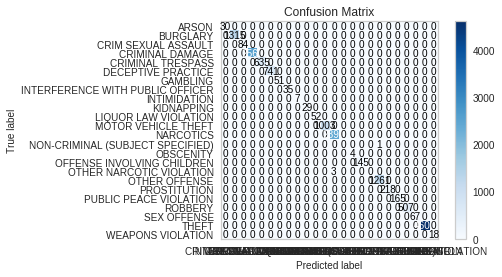

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import scikitplot as skplt

# Assuming you have defined your classifier as 'clf' and have X_test and y_test data
test_pred = DT.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Plot the confusion matrix
skplt.metrics.plot_confusion_matrix(y_test, test_pred)

# Display the plot
plt.show()



In [26]:
from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train,y_train)
print('*'*20)

# prediction
train_prediction= rfc.predict(X_train)
test_prediction= rfc.predict(X_test)
print('*'*20)

# evaluation
from sklearn.metrics import accuracy_score
print('train accuracy:',accuracy_score(y_test,test_prediction))
print('test accuracy:',accuracy_score(y_train,train_prediction))
print('*'*20)

# cross validation score
from sklearn.model_selection import cross_val_score
score=cross_val_score(rfc,X,y,cv=5)
print(score.mean())
print('*'*20)

#  prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*'*20)

# Accuracy score
RF_SC = accuracy_score(test_prediction,y_test)
print(f"{round(RF_SC*100,2)}% Accurate")

********************
********************
train accuracy: 0.9933475586795532
test accuracy: 0.9998744743613883
********************
0.99556914398281
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      0.83      0.91        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       0.98      1.00      0.99       635
              DECEPTIVE PRACTICE       0.99      1.00      1.00       741
                        GAMBLING       0.92      0.92      0.92        51
INTERFERENCE WITH PUBLIC OFFICER       0.94      0.94      0.94        35
                    INTIMIDATION       0.67      0.29      0.40         7
                      KIDNAPPING       0.71      0.41      0.52        29
            LIQ

In [27]:
from xgboost import XGBClassifier

XGB = XGBClassifier()
XGB.fit(X_train, y_train)


train_prediction= XGB.predict(X_train)
test_prediction= XGB.predict(X_test)
print('*'*20)

print('test accuracy:',accuracy_score(y_test,test_prediction))
print('train accuracy:',accuracy_score(y_train,train_prediction))
print('*'*20)

#  prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*'*20)

# Accuracy score
XGB_SC = accuracy_score(test_prediction,y_test)
print(f"{round(XGB_SC*100,2)}% Accurate")


********************
test accuracy: 0.9996234467177105
train accuracy: 0.9999529278855206
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      1.00      1.00        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       1.00      1.00      1.00       635
              DECEPTIVE PRACTICE       1.00      1.00      1.00       741
                        GAMBLING       1.00      1.00      1.00        51
INTERFERENCE WITH PUBLIC OFFICER       1.00      1.00      1.00        35
                    INTIMIDATION       1.00      1.00      1.00         7
                      KIDNAPPING       1.00      1.00      1.00        29
            LIQUOR LAW VIOLATION       1.00      1.00      1.00        52


In [28]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

# prediction
train_prediction= LR.predict(X_train)
test_prediction= LR.predict(X_test)
print('*'*20)

# evaluation
from sklearn.metrics import accuracy_score
print('test accuracy:',accuracy_score(y_test,test_prediction))
print('train accuracy:',accuracy_score(y_train,train_prediction))
print('*'*20)

print(classification_report(y_test,test_pred))

print('*'*20)


lr_HSC = accuracy_score(y_test,test_prediction)
print(f"{round(lr_HSC*100,2)}% Accurate")

********************
test accuracy: 0.7382954688088365
train accuracy: 0.7368354986505994
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      1.00      1.00        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       1.00      1.00      1.00       635
              DECEPTIVE PRACTICE       1.00      1.00      1.00       741
                        GAMBLING       1.00      1.00      1.00        51
INTERFERENCE WITH PUBLIC OFFICER       1.00      1.00      1.00        35
                    INTIMIDATION       1.00      1.00      1.00         7
                      KIDNAPPING       1.00      1.00      1.00        29
            LIQUOR LAW VIOLATION       1.00      1.00      1.00        52


In [29]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(random_state=42)
gbc.fit(X_train,y_train)
print('*'*20)

# prediction
train_prediction= gbc.predict(X_train)
test_prediction= gbc.predict(X_test)
print('*'*20)

# evaluation
from sklearn.metrics import accuracy_score
print('test accuracy:',accuracy_score(y_test,test_prediction))
print('train accuracy:',accuracy_score(y_train,train_prediction))
print('*'*20)


#  prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*'*20)

# Accuracy score
gb_SC = accuracy_score(test_prediction,y_test)
print(f"{round(gb_SC*100,2)}% Accurate")

********************
********************
test accuracy: 0.9996234467177105
train accuracy: 1.0
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      1.00      1.00        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       1.00      1.00      1.00       635
              DECEPTIVE PRACTICE       1.00      1.00      1.00       741
                        GAMBLING       1.00      1.00      1.00        51
INTERFERENCE WITH PUBLIC OFFICER       1.00      1.00      1.00        35
                    INTIMIDATION       1.00      1.00      1.00         7
                      KIDNAPPING       1.00      1.00      1.00        29
            LIQUOR LAW VIOLATION       1.00      1.00      1.00     

In [30]:
# Neural Network
# Create Model with configuration 
nn_model = MLPClassifier(solver='adam', 
                         alpha=1e-5,
                         hidden_layer_sizes=(40,), 
                         random_state=1,
                         max_iter=1000                         
                        )

# Model Training
nn_model.fit(X_train,
             y_train)
# Prediction
test_prediction = nn_model.predict(X_test) 
train_prediction = nn_model.predict(X_train) 


In [31]:
# evaluation
from sklearn.metrics import accuracy_score
print('test accuracy:',accuracy_score(y_test,test_prediction))
print('train accuracy:',accuracy_score(y_train,train_prediction))

print('*'*20)

#  prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*'*20)

# Accuracy score
mlp_SC = accuracy_score(test_prediction,y_test)
print(f"{round(mlp_SC*100,2)}% Accurate")

test accuracy: 0.9823019957323962
train accuracy: 0.9837130483901337
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      0.93      0.97        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       1.00      1.00      1.00       635
              DECEPTIVE PRACTICE       1.00      1.00      1.00       741
                        GAMBLING       0.96      0.86      0.91        51
INTERFERENCE WITH PUBLIC OFFICER       0.97      1.00      0.99        35
                    INTIMIDATION       1.00      1.00      1.00         7
                      KIDNAPPING       0.11      0.48      0.18        29
            LIQUOR LAW VIOLATION       0.98      1.00      0.99        52
             MOTOR VE

In [32]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming you have imported and initialized your classifiers (DT, rfc, nn_model, XGB, LR, gbc)

# Create Model with configuration
eclf1 = VotingClassifier(estimators=[
    ('Decision', DT),
    ('Random', rfc),
    ('nn', nn_model),
    ('Xgboost', XGB),
    ('logistic', LR),
    ('gradient', gbc)
], 
weights=[1, 1, 1, 1, 1, 1],
flatten_transform=True)

# Assuming you have X_train, X_test, y_train, y_test initialized
eclf1 = eclf1.fit(X_train, y_train) 

# Prediction
test_prediction = eclf1.predict(X_test) 
train_prediction = eclf1.predict(X_train) 

# Evaluation
print('test accuracy:', accuracy_score(y_test, test_prediction))
print('train accuracy:', accuracy_score(y_train, train_prediction))

print('*' * 20)

# Prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*' * 20)

# Accuracy score
voting = accuracy_score(test_prediction, y_test)
print(f"{round(voting * 100, 2)}% Accurate")


test accuracy: 0.998368269110079
train accuracy: 0.9999529278855206
********************
                                  precision    recall  f1-score   support

                           ARSON       1.00      1.00      1.00        30
                        BURGLARY       1.00      1.00      1.00      1315
             CRIM SEXUAL ASSAULT       1.00      1.00      1.00        84
                 CRIMINAL DAMAGE       1.00      1.00      1.00      2562
               CRIMINAL TRESPASS       1.00      1.00      1.00       635
              DECEPTIVE PRACTICE       1.00      1.00      1.00       741
                        GAMBLING       1.00      1.00      1.00        51
INTERFERENCE WITH PUBLIC OFFICER       1.00      1.00      1.00        35
                    INTIMIDATION       1.00      1.00      1.00         7
                      KIDNAPPING       1.00      1.00      1.00        29
            LIQUOR LAW VIOLATION       1.00      1.00      1.00        52
             MOTOR VEH

In [42]:
score = [DT_SC,RF_SC,XGB_SC,lr_HSC,gb_SC,mlp_SC,voting]
Models = pd.DataFrame({
    'n_neighbors': ["Decision Tree","Random Forest","XGBoost", "Logistic Regression",'GreadientBoostClassifier','MLPClassifier','Voting'],
    'Score': score})
Models.sort_values(by='Score', ascending=False)

,n_neighbors,Score
0,Decision Tree,0.999749
2,XGBoost,0.999623
4,GreadientBoostClassifier,0.999623
6,Voting,0.998368
1,Random Forest,0.993348
5,MLPClassifier,0.982302
3,Logistic Regression,0.738295


In [19]:

import pickle
#save the model
model = DT  # Your machine learning model object
file_path = 'Dt_crime1.pkl'  # Path to the file where you want to save the model
with open(file_path, 'wb') as file:
    pickle.dump(model, file)

In [20]:
# load the model
import pickle

file_path = 'Dt_crime1.pkl'  # Path to the saved model file
with open(file_path, 'rb') as file:
    loaded_model = pickle.load(file)

In [25]:
X_train

,IUCR,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Year,Latitude,Longitude,Month,Day
13245,925,0,0,413,4.0,7.0,48.0,7,2005,41.732532,-87.569528,7,26
24178,810,0,0,1433,14.0,32.0,24.0,6,2008,41.909068,-87.659851,6,5
22496,1130,0,0,1132,11.0,24.0,26.0,11,2011,41.875286,-87.724176,3,18
64500,1310,0,0,1121,11.0,27.0,23.0,14,2006,41.891827,-87.713085,4,22
68915,820,0,0,1411,14.0,33.0,21.0,6,2007,41.937294,-87.702670,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,1320,0,0,934,9.0,20.0,61.0,14,2007,41.798945,-87.648921,1,13
54886,2825,0,1,1732,17.0,30.0,21.0,26,2009,41.941479,-87.726031,1,31
76820,820,0,0,1014,10.0,24.0,29.0,6,2006,41.858015,-87.724935,1,26
860,610,0,0,914,9.0,20.0,61.0,5,2005,41.811438,-87.668695,2,14


In [22]:
loaded_model.predict([[925,0,0,413,4.0,7.0,48.0,7,2005,41.732532,-87.569528,7,26]])

array([12], dtype=int64)

In [23]:
loaded_model.predict([[820,0,0,1915,19.0,46.0,3.0,6,2015,41.954477,-87.655252,6,24]])

array([26], dtype=int64)